<a href="https://colab.research.google.com/github/WTavasi/MataPredict/blob/main/MLProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matatu Overcrowding Prediction

This notebook predicts whether a matatu ride will be overcrowded. A ride counts as overcrowded when 80% or more of its seats are sold.

The input is what we know before the ride: the time, the day, the month, the origin town, the road, the vehicle type and the payment method. The output is overcrowded or not overcrowded.

## What is in this notebook
| Part | What it does |
|---|---|
| Part 1 | Prepares the data. Turns the raw ticket data into one row per ride, adds map information and saves `matatu_merged_clean.csv`. |
| Part 2 | Trains two models (Logistic Regression and a Decision Tree), compares them and saves the final model. |
| Part 3 | Draws charts that show when and where overcrowding happens. |
| Part 4 | Lists the data sources, the assumptions and the limits of the results. |
| Part 5 | Gives the steps to deploy the model as a web app. |

Each code cell has a short description above it that says what the cell does.

## Before you run it
1. Run the cells from top to bottom.
2. Part 1 asks you to upload three files: the Zindi zip, `GIS_DATA_2019.zip` and `waze_dataset.csv`. The download links are in Part 4.
3. If you already have `matatu_merged_clean.csv`, you can skip Part 1. Upload that file in the Colab file panel (folder icon on the left) and start at Part 2.
4. The last chart in Part 3 also needs `waze_dataset.csv` in the file panel.

# Part 1: Data preparation

### Step 1: Install libraries
Colab already has most libraries. This line installs a few extra ones: `pandas` (tables), `numpy` (maths) and `scikit-learn` (machine learning). The `-q` flag keeps the output short.

In [2]:
# Cell 1 - Install all dependencies
!pip install pandas numpy scikit-learn requests tqdm kaggle -q

### Step 2: Load the Zindi ticket data
Zindi gave us one row for every ticket sold. This cell:
1. Asks you to upload the Zindi zip file.
2. Unzips it. The training data is a zip inside a zip, so it unzips twice.
3. Loads three files into tables: `train_df` (the tickets we learn from), `test_df` (the rides to predict in the original competition) and `sub_df` (the competition's answer format).

It then prints the size of each file and the first 3 rows.

In [3]:
# Cell 2 - Load and inspect all Zindi files
# Upload the zip from Zindi when prompted, or upload the extracted CSVs directly

from google.colab import files
import pandas as pd
import zipfile
import io
import os

# Upload the zip file
print("Upload the Zindi zip file (traffic-jam-predicting-peoples-movement-into-nairobi...zip)")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

# Extract outer zip
with zipfile.ZipFile(io.BytesIO(uploaded[zip_filename])) as outer_zip:
    outer_zip.extractall("/content/zindi_raw/")

# The train data is nested inside a second zip
inner_zip_path = "/content/zindi_raw/train_revised_11.09.2018.zip"
with zipfile.ZipFile(inner_zip_path) as inner_zip:
    inner_zip.extractall("/content/zindi_raw/")

# Load all three files
train_df = pd.read_csv("/content/zindi_raw/train_revised.csv")
test_df  = pd.read_csv("/content/zindi_raw/test_questions.csv")
sub_df   = pd.read_csv("/content/zindi_raw/sample_submission.csv")

print(f"Train shape:  {train_df.shape}  - one row per ticket sold")
print(f"Test shape:   {test_df.shape}   - one row per ride (no tickets)")
print(f"Sample sub:   {sub_df.shape}    - target format: ride_id + number_of_ticket")
print()
print(train_df.head(3).to_string())

Upload the Zindi zip file (traffic-jam-predicting-peoples-movement-into-nairobi...zip)


Saving traffic-jam-predicting-peoples-movement-into-nairobi20250307-26022-9b8vw1.zip to traffic-jam-predicting-peoples-movement-into-nairobi20250307-26022-9b8vw1.zip
Train shape:  (51645, 10)  - one row per ticket sold
Test shape:   (1111, 7)   - one row per ride (no tickets)
Sample sub:   (1111, 2)    - target format: ride_id + number_of_ticket

   ride_id seat_number payment_method payment_receipt travel_date travel_time travel_from travel_to car_type  max_capacity
0     1442         15A          Mpesa      UZUEHCBUSO    17-10-17        7:15      Migori   Nairobi      Bus            49
1     5437         14A          Mpesa      TIHLBUSGTE    19-11-17        7:12      Migori   Nairobi      Bus            49
2     5710          8B          Mpesa      EQX8Q5G19O    26-11-17        7:05      Keroka   Nairobi      Bus            49


### Step 3: Turn tickets into rides and create the target
The data has one row per ticket, but we want one row per ride. This cell:
1. Joins the date and time columns into one timestamp.
2. Counts the tickets for each ride. That count is `seats_sold`.
3. Adds the hour, minute, day name and month. It also marks peak hours (5am to 9am and 4pm to 8pm) with `is_peak`.
4. Creates the target. `occupancy_rate` is seats sold divided by seats available. If it is 0.8 or higher, `is_overcrowded` is 1. Otherwise it is 0. The models try to predict this column.
5. Assigns each origin town to the road it uses to enter Nairobi. This mapping is an assumption made by the team (see Part 4).

In [4]:
# Cell 3 - Aggregate tickets per ride and engineer features
# This converts the ticket-level data into ride-level data
# which is the correct granularity for your ML model

import pandas as pd

# --- Parse timestamps ---
train_df["travel_datetime"] = pd.to_datetime(
    train_df["travel_date"].astype(str) + " " + train_df["travel_time"].astype(str),
    format="%d-%m-%y %H:%M",
    errors="coerce"
)

# Verify parsing worked
bad_timestamps = train_df["travel_datetime"].isnull().sum()
print(f"Unparseable timestamps: {bad_timestamps}")
train_df = train_df.dropna(subset=["travel_datetime"])

# --- Aggregate from ticket level to ride level ---
seats_per_ride = (
    train_df.groupby("ride_id")
    .agg(
        seats_sold      = ("seat_number",   "count"),
        max_capacity    = ("max_capacity",  "first"),
        travel_from     = ("travel_from",   "first"),
        travel_to       = ("travel_to",     "first"),
        travel_datetime = ("travel_datetime","first"),
        car_type        = ("car_type",      "first"),
        payment_method  = ("payment_method","first")
    )
    .reset_index()
)

# --- Time features ---
seats_per_ride["hour"]        = seats_per_ride["travel_datetime"].dt.hour
seats_per_ride["minute"]      = seats_per_ride["travel_datetime"].dt.minute
seats_per_ride["day_of_week"] = seats_per_ride["travel_datetime"].dt.day_name()
seats_per_ride["month"]       = seats_per_ride["travel_datetime"].dt.month
seats_per_ride["timestamp_bin"] = seats_per_ride["travel_datetime"].dt.round("30min")

# Peak hours: 5am-9am (morning), 4pm-8pm (evening)
seats_per_ride["is_peak"] = seats_per_ride["hour"].apply(
    lambda h: 1 if (5 <= h <= 9) or (16 <= h <= 20) else 0
)

# --- Overcrowding target ---
# occupancy_rate = proportion of seats filled per ride
seats_per_ride["occupancy_rate"] = (
    seats_per_ride["seats_sold"] / seats_per_ride["max_capacity"]
)

# Binary label: overcrowded if >= 80% full
seats_per_ride["is_overcrowded"] = (
    seats_per_ride["occupancy_rate"] >= 0.8
).astype(int)

# --- Drop travel_to (always Nairobi, zero variance) ---
seats_per_ride = seats_per_ride.drop(columns=["travel_to"])

# --- Map origin towns to Nairobi entry corridor ---
# ASSUMPTION: this town-to-road mapping was chosen by the team.
# The Zindi data does not say which road each town uses.
# State this in the report.
corridor_map = {
    "Kisii":     "Mombasa Road",
    "Migori":    "Mombasa Road",
    "Sirare":    "Mombasa Road",
    "Rongo":     "Mombasa Road",
    "Kehancha":  "Mombasa Road",
    "Awendo":    "Mombasa Road",
    "Nyachenge": "Mombasa Road",
    "Homa Bay":  "Langata Road",
    "Mbita":     "Langata Road",
    "Kendu Bay": "Langata Road",
    "Keroka":    "Ngong Road",
    "Keumbu":    "Ngong Road",
    "Kijauri":   "Thika Road",
    "Sori":      "Thika Road"
}
seats_per_ride["route"] = seats_per_ride["travel_from"].map(corridor_map).fillna("unknown")

# --- Summary ---
print(f"\nRide-level dataset shape: {seats_per_ride.shape}")
print(f"Overcrowding rate: {seats_per_ride['is_overcrowded'].mean():.2%}")
print(f"\nCar type breakdown:\n{seats_per_ride['car_type'].value_counts()}")
print(f"\nRoute distribution:\n{seats_per_ride['route'].value_counts()}")
print(f"\nOccupancy rate stats:\n{seats_per_ride['occupancy_rate'].describe()}")
print()
print(seats_per_ride.head(5).to_string())

Unparseable timestamps: 0

Ride-level dataset shape: (6249, 16)
Overcrowding rate: 23.04%

Car type breakdown:
car_type
Bus        3189
shuttle    3060
Name: count, dtype: int64

Route distribution:
route
Mombasa Road    4888
Thika Road       576
Langata Road     378
Ngong Road       332
unknown           75
Name: count, dtype: int64

Occupancy rate stats:
count    6249.000000
mean        0.390467
std         0.359722
min         0.020408
25%         0.090909
50%         0.224490
75%         0.727273
max         1.090909
Name: occupancy_rate, dtype: float64

   ride_id  seats_sold  max_capacity travel_from     travel_datetime car_type payment_method  hour  minute day_of_week  month       timestamp_bin  is_peak  occupancy_rate  is_overcrowded         route
0     1442           1            49      Migori 2017-10-17 07:15:00      Bus          Mpesa     7      15     Tuesday     10 2017-10-17 07:00:00        1        0.020408               0  Mombasa Road
1     5437           1           

### Step 4: Load the Digital Matatus map data
Digital Matatus is a project that mapped Nairobi's matatu routes. Its download holds shapefiles, which are map files with the route lines and the stop locations. This cell asks you to upload `GIS_DATA_2019.zip`, unzips it and lists the files inside.

In [5]:
# Cell 4 - Load Digital Matatus GIS shapefiles
# Upload GIS_DATA_2019.zip when prompted

from google.colab import files
import zipfile
import io
import os

print("Upload GIS_DATA_2019.zip from the Digital Matatus project")
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(io.BytesIO(uploaded[zip_filename])) as z:
    z.extractall("/content/gis_data/")

print("Extracted files:", os.listdir("/content/gis_data/"))

Upload GIS_DATA_2019.zip from the Digital Matatus project


Saving GIS_DATA_2019.zip to GIS_DATA_2019.zip
Extracted files: ['stops.shx', 'stops.cpg', 'shapes.cpg', 'stops.dbf', 'stops.prj', 'shapes.qpj', 'shapes.shp', 'stops.qpj', 'stops.shp', 'shapes.dbf', 'shapes.shx', 'README.txt', 'shapes.prj']


### Step 4b: Read the map files
Installs `geopandas` (pandas for map data) and reads two files: the route lines (`shapes`) and the bus stops (`stops`). It prints how many routes and stops there are and shows a sample of route names.

In [6]:
# Cell 4b - Install geopandas and load both shapefiles

!pip install geopandas -q

import geopandas as gpd
import pandas as pd

shapes_gdf = gpd.read_file("/content/gis_data/shapes.shp")
stops_gdf  = gpd.read_file("/content/gis_data/stops.shp")

print(f"Routes (shapes): {shapes_gdf.shape[0]} polylines, {shapes_gdf['route_name'].nunique()} unique routes")
print(f"Stops:           {stops_gdf.shape[0]} stop points")
print(f"CRS:             {shapes_gdf.crs}  (no reprojection needed)")
print()
print("Sample routes:")
print(shapes_gdf[["route_name","route_long","headsign","direction"]].head(10).to_string())

Routes (shapes): 272 polylines, 136 unique routes
Stops:           4284 stop points
CRS:             EPSG:4326  (no reprojection needed)

Sample routes:
  route_name                      route_long  headsign  direction
0        106            Koja-UN-Ruaka-Banana      Koja          0
1        106            Koja-UN-Ruaka-Banana    Banana          1
2        107         Odeon-UN-Ruaka-Ndenderu     Odeon          0
3        107         Odeon-UN-Ruaka-Ndenderu  Ndenderu          1
4        108  UN-New Muthaiga-Gachie-Gichagi      UNEP          0
5        108  UN-New Muthaiga-Gachie-Gichagi   Gichagi          1
6       114R     Ngara-Rwaka-Ndenderu-Limuru     Ngara          0
7       114R     Ngara-Rwaka-Ndenderu-Limuru    Limuru          1
8        116        Koja-Ngara-Banana-Limuru      Koja          0
9        116        Koja-Ngara-Banana-Limuru    Limuru          1


### Step 4c: Label each route with a corridor
The map data does not say which main road a route belongs to. This cell guesses from the route name. A name that contains "thika" or "ruiru" is tagged Thika Road. A name that contains "mombasa" or "syokimau" is tagged Mombasa Road, and so on. A route that matches no keyword is tagged `other`. The output shows how many routes each corridor got.

This is keyword matching, so some routes may be tagged wrongly, for example a route whose name mentions two places.

In [7]:
# Cell 4c - Tag each route with its Nairobi corridor
# We match route_long names to the six major corridors
# This is the bridge between Digital Matatus route geometry
# and the corridor labels we assigned in the Zindi data

corridor_keywords = {
    "Ngong Road":   ["ngong","dagoretti","kawangware","rongai","kibera","langata"],
    "Thika Road":   ["thika","kasarani","ruiru","githurai","roysambu","membley"],
    "Waiyaki Way":  ["waiyaki","westlands","kangemi","uthiru","mountainview","regen"],
    "Jogoo Road":   ["jogoo","umoja","eastlands","donholm","embakasi"],
    "Mombasa Road": ["mombasa","mlolongo","athi","syokimau","imara","south b"],
    "Langata Road": ["langata","karen","bomas","hardy","wilson"]
}

def tag_corridor(route_long):
    if not isinstance(route_long, str):
        return "other"
    text = route_long.lower()
    for corridor, keywords in corridor_keywords.items():
        if any(kw in text for kw in keywords):
            return corridor
    return "other"

shapes_gdf["corridor"] = shapes_gdf["route_long"].apply(tag_corridor)

print("Routes per corridor:")
print(shapes_gdf["corridor"].value_counts().to_string())

Routes per corridor:
corridor
other           116
Ngong Road       40
Jogoo Road       38
Thika Road       34
Waiyaki Way      24
Mombasa Road     16
Langata Road      4


### Step 4d: Give each corridor a map position
For each corridor, this cell finds the smallest box on the map that contains all its routes. The middle of that box is the centroid. It also counts the routes in each corridor. The result is saved as `corridor_bounds.csv` for the merge step.

Each corridor has one fixed centroid, so `centroid_lat` and `centroid_lon` only repeat the corridor name. They add no new information to the model.

In [8]:
# Cell 4d - Extract corridor summary: bounding box and stop density per corridor
# This gives each corridor a geographic footprint
# which we will use as a reference feature during visualization

import numpy as np

# Get the geometry bounds per corridor (min/max lat/lon)
corridor_bounds = (
    shapes_gdf.groupby("corridor")
    .agg(
        route_count  = ("route_name", "nunique"),
        min_lat      = ("geometry",   lambda g: g.bounds["miny"].min()),
        max_lat      = ("geometry",   lambda g: g.bounds["maxy"].max()),
        min_lon      = ("geometry",   lambda g: g.bounds["minx"].min()),
        max_lon      = ("geometry",   lambda g: g.bounds["maxx"].max()),
    )
    .reset_index()
)

# Compute centroid per corridor
corridor_bounds["centroid_lat"] = (corridor_bounds["min_lat"] + corridor_bounds["max_lat"]) / 2
corridor_bounds["centroid_lon"] = (corridor_bounds["min_lon"] + corridor_bounds["max_lon"]) / 2

print("Corridor geographic summary:")
print(corridor_bounds.to_string())

# Save for later use in visualization
corridor_bounds.to_csv("/content/corridor_bounds.csv", index=False)

Corridor geographic summary:
       corridor  route_count   min_lat   max_lat    min_lon    max_lon  centroid_lat  centroid_lon
0    Jogoo Road           19 -1.348250 -1.248715  36.820217  36.996873     -1.298482     36.908545
1  Langata Road            2 -1.365610 -1.286082  36.707114  36.827778     -1.325846     36.767446
2  Mombasa Road            8 -1.477248 -1.283131  36.802869  36.989681     -1.380190     36.896275
3    Ngong Road           20 -1.430452 -1.219091  36.655353  36.830383     -1.324771     36.742868
4    Thika Road           17 -1.329979 -1.033820  36.779265  37.078487     -1.181899     36.928876
5   Waiyaki Way           12 -1.291859 -1.105596  36.629578  36.830973     -1.198728     36.730276
6         other           58 -1.338996 -1.056380  36.641678  36.996878     -1.197688     36.819278


### Step 4e: Make a list of bus stops
Keeps the useful stop columns (id, name, latitude, longitude, trip count), removes stops with no location and tags each stop with a corridor, using the same keyword method as before. Saves the result as `digital_matatus_stops.csv`. This file is only a reference for map charts. The models do not use it.

In [9]:
# Cell 4e - Extract stop-level data as a flat CSV reference
# stop_lat, stop_lon, trip_count are the useful columns for the project

stops_clean = stops_gdf[["stop_id","stop_name","stop_lat","stop_lon","trip_count"]].copy()
stops_clean = stops_clean.dropna(subset=["stop_lat","stop_lon"])

# Tag stops with corridor using the same keyword logic on stop names
def tag_stop_corridor(name):
    if not isinstance(name, str):
        return "other"
    name = name.lower()
    for corridor, keywords in corridor_keywords.items():
        if any(kw in name for kw in keywords):
            return corridor
    return "other"

stops_clean["corridor"] = stops_clean["stop_name"].apply(tag_stop_corridor)

print(f"Clean stops: {stops_clean.shape}")
print(stops_clean.head(10).to_string())

stops_clean.to_csv("/content/digital_matatus_stops.csv", index=False)
print("\nSaved to /content/digital_matatus_stops.csv")

Clean stops: (4284, 6)
   stop_id            stop_name  stop_lat   stop_lon  trip_count corridor
0  0001RLW             Railways -1.290884  36.828242          14    other
1  0002KOJ                 Koja -1.281230  36.822596           0    other
2  0003NGR                Ngara -1.274395  36.823806           0    other
3  0004ODN                Odeon -1.282769  36.825032           0    other
4  0005AMB   Kencom/Ambassadeur -1.285963  36.826048           0    other
5  0006BSS          Bus Station -1.287191  36.828881           0    other
6  0007COM           Commercial -1.284282  36.826188           0    other
7  0008MUT             Muthurwa -1.288049  36.833947           0    other
8  0010OTC                  OTC -1.284947  36.830994           0    other
9  0011TUS  Tusker/Ronald Ngala -1.285346  36.828574           0    other

Saved to /content/digital_matatus_stops.csv


### Step 5: Load the Waze dataset
This is a separate dataset about how people use the Waze app. It is not about Nairobi or matatus. It has no dates or routes, so it cannot be merged with the ride data. It is used only as background reference. This cell asks you to upload it, then prints its size, columns, missing values and how many users stayed or churned (stopped using the app).

In [10]:
# Cell 5 - Load and profile the Waze dataset
# This dataset characterises general urban driver behaviour.
# It is a user-level engagement dataset with no timestamps or
# route data, so it is used as a behavioural reference rather
# than a direct merge target.

from google.colab import files
import pandas as pd
import io

print("Upload waze_dataset.csv from Kaggle")
uploaded = files.upload()

waze_df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print(f"Shape: {waze_df.shape}")
print(f"\nColumns: {list(waze_df.columns)}")
print(f"\nNull counts:\n{waze_df.isnull().sum()}")
print(f"\nLabel distribution:\n{waze_df['label'].value_counts()}")

Upload waze_dataset.csv from Kaggle


Saving waze_dataset.csv to waze_dataset.csv
Shape: (14999, 13)

Columns: ['ID', 'label', 'sessions', 'drives', 'total_sessions', 'n_days_after_onboarding', 'total_navigations_fav1', 'total_navigations_fav2', 'driven_km_drives', 'duration_minutes_drives', 'activity_days', 'driving_days', 'device']

Null counts:
ID                           0
label                      700
sessions                     0
drives                       0
total_sessions               0
n_days_after_onboarding      0
total_navigations_fav1       0
total_navigations_fav2       0
driven_km_drives             0
duration_minutes_drives      0
activity_days                0
driving_days                 0
device                       0
dtype: int64

Label distribution:
label
retained    11763
churned      2536
Name: count, dtype: int64


### Step 5b: Clean the Waze data
Removes the 700 rows with no stayed/churned label. Then it creates three ratios for each user: kilometres per drive, driving days divided by active days, and sessions per active day. If a ratio would divide by zero, it is set to 0.

In [11]:
# Cell 5b - Clean and derive behavioural reference features

# Drop rows where label is null (700 rows have no churn label)
waze_clean = waze_df.dropna(subset=["label"]).copy()
print(f"After dropping unlabelled rows: {waze_clean.shape}")

# Derive meaningful aggregate features
waze_clean["km_per_drive"] = (
    waze_clean["driven_km_drives"] / waze_clean["drives"].replace(0, pd.NA)
)
waze_clean["drive_intensity_ratio"] = (
    waze_clean["driving_days"] / waze_clean["activity_days"].replace(0, pd.NA)
)
waze_clean["sessions_per_day"] = (
    waze_clean["sessions"] / waze_clean["activity_days"].replace(0, pd.NA)
)

# Fill derived NaNs caused by zero denominators
waze_clean["km_per_drive"]          = waze_clean["km_per_drive"].fillna(0)
waze_clean["drive_intensity_ratio"] = waze_clean["drive_intensity_ratio"].fillna(0)
waze_clean["sessions_per_day"]      = waze_clean["sessions_per_day"].fillna(0)

print(f"\nDerived feature stats:")
print(waze_clean[["km_per_drive","drive_intensity_ratio","sessions_per_day"]].describe().to_string())

After dropping unlabelled rows: (14299, 13)

Derived feature stats:
       km_per_drive  drive_intensity_ratio  sessions_per_day
count  14299.000000           14299.000000      14299.000000
mean     232.269197               0.735071         10.258022
std      616.197409               0.273400         22.523488
min        0.000000               0.000000          0.000000
25%       32.486524               0.631579          1.500000
50%       72.947059               0.800000          3.960000
75%      179.347527               0.960000          9.400000
max    15777.426560               1.000000        479.000000


/tmp/ipykernel_1794/2110309150.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  waze_clean["km_per_drive"]          = waze_clean["km_per_drive"].fillna(0)
/tmp/ipykernel_1794/2110309150.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  waze_clean["drive_intensity_ratio"] = waze_clean["drive_intensity_ratio"].fillna(0)
/tmp/ipykernel_1794/2110309150.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future

### Step 5c: Summarise the Waze data
Calculates a few average values from the Waze data, such as the average kilometres per drive and the churn rate. It also saves the cleaned Waze table as `waze_clean.csv`. These numbers are background statistics for the report. The matatu model does not use them.

In [12]:
# Cell 5c - Extract dataset-level behavioural constants
# These are used as reference statistics in your methodology
# and in the visualisation section, not as row-level features

waze_stats = {
    "avg_km_per_drive":          waze_clean["km_per_drive"].mean(),
    "median_km_per_drive":       waze_clean["km_per_drive"].median(),
    "avg_drive_intensity":       waze_clean["drive_intensity_ratio"].mean(),
    "avg_driving_days_per_month":waze_clean["driving_days"].mean(),
    "churn_rate":                (waze_clean["label"] == "churned").mean(),
    "iphone_share":              (waze_clean["device"] == "iPhone").mean(),
}

print("Waze behavioural reference constants:")
for k, v in waze_stats.items():
    print(f"  {k}: {v:.4f}")

# Save cleaned Waze data for the visualisation cells
waze_clean.to_csv("/content/waze_clean.csv", index=False)
print("\nSaved to /content/waze_clean.csv")

Waze behavioural reference constants:
  avg_km_per_drive: 232.2692
  median_km_per_drive: 72.9471
  avg_drive_intensity: 0.7351
  avg_driving_days_per_month: 12.1825
  churn_rate: 0.1774
  iphone_share: 0.6452

Saved to /content/waze_clean.csv


### Step 6: Combine the ride data with the map data
Joins the ride table to the corridor table, so each ride gets `route_count`, `centroid_lat` and `centroid_lon`. Rides with an unknown corridor (75 of them) get `gis_missing = True` and are filled with the median values, so no cell is empty. The cell then keeps the chosen columns, removes duplicate rows and sorts the rides by time. The result is the table `df_final`.

In [13]:
# Cell 6 - Merge Zindi ride data with Digital Matatus corridor bounds

import pandas as pd

corridor_bounds = pd.read_csv("/content/corridor_bounds.csv")

df_merged = pd.merge(
    seats_per_ride,
    corridor_bounds[["corridor", "route_count", "centroid_lat", "centroid_lon"]],
    left_on="route",
    right_on="corridor",
    how="left"
)

df_merged = df_merged.drop(columns=["corridor"])
df_merged["gis_missing"] = df_merged["centroid_lat"].isna()

# Fill the 75 unknown rows
df_merged["route_count"]  = df_merged["route_count"].fillna(0)
df_merged["centroid_lat"] = df_merged["centroid_lat"].fillna(df_merged["centroid_lat"].median())
df_merged["centroid_lon"] = df_merged["centroid_lon"].fillna(df_merged["centroid_lon"].median())

# Build df_final here so Cell 7 can access it
final_columns = [
    "ride_id", "route", "travel_from", "timestamp_bin",
    "hour", "minute", "day_of_week", "month",
    "car_type", "payment_method", "is_peak",
    "seats_sold", "max_capacity", "occupancy_rate", "is_overcrowded",
    "route_count", "centroid_lat", "centroid_lon", "gis_missing"
]

df_final = (
    df_merged[final_columns]
    .drop_duplicates()
    .sort_values("timestamp_bin")
    .reset_index(drop=True)
)

# Confirm nulls are gone
print(df_final[["route_count","centroid_lat","centroid_lon"]].isnull().sum())
print(df_final.shape)

route_count     0
centroid_lat    0
centroid_lon    0
dtype: int64
(6249, 19)


### Step 7: Save the clean dataset
Saves `df_final` as `matatu_merged_clean.csv`. This file is the output of Part 1 and the input to Parts 2 and 3. The cell also confirms there are no missing values and prints how many rides are overcrowded and how many are not.

Colab deletes its files when the session ends. After this cell, download `matatu_merged_clean.csv` from the file panel so you do not have to repeat Part 1.

In [14]:
# Cell 7 - Output the final clean CSV

df_final.to_csv("/content/matatu_merged_clean.csv", index=False)
print(f"Final dataset: {df_final.shape[0]} rows, {df_final.shape[1]} columns")
print(f"\nNull check:\n{df_final.isnull().sum()}")
print(f"\nTarget distribution:\n{df_final['is_overcrowded'].value_counts()}")
print(f"\nSample:\n{df_final.head(3).to_string()}")

Final dataset: 6249 rows, 19 columns

Null check:
ride_id           0
route             0
travel_from       0
timestamp_bin     0
hour              0
minute            0
day_of_week       0
month             0
car_type          0
payment_method    0
is_peak           0
seats_sold        0
max_capacity      0
occupancy_rate    0
is_overcrowded    0
route_count       0
centroid_lat      0
centroid_lon      0
gis_missing       0
dtype: int64

Target distribution:
is_overcrowded
0    4809
1    1440
Name: count, dtype: int64

Sample:
   ride_id         route travel_from       timestamp_bin  hour  minute day_of_week  month car_type payment_method  is_peak  seats_sold  max_capacity  occupancy_rate  is_overcrowded  route_count  centroid_lat  centroid_lon  gis_missing
0     1442  Mombasa Road      Migori 2017-10-17 07:00:00     7      15     Tuesday     10      Bus          Mpesa        1           1            49        0.020408               0          8.0      -1.38019     36.896275        F

# Part 2: Modelling

##Handling Imports

### Load the machine learning libraries
Loads what Part 2 needs: the tools to split the data and cross-validate, the two models (Logistic Regression and Decision Tree) and the tools for scores and charts. The commented-out lines at the bottom are an old upload step. They are switched off because the CSV is already in the session from Part 1.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc,
                             precision_recall_curve)

# from google.colab import files

# print("Please click 'Choose Files' to upload matatu_merged_clean.csv:")
# uploaded = files.upload()

##Baseline Modelling (Member 4)

### Train and compare the two models
This cell does the whole modelling job, in this order:

1. **Load and prepare.** Reads `matatu_merged_clean.csv`. Removes `ride_id` and `timestamp_bin` because they only identify a ride. Removes `seats_sold` and `occupancy_rate` because the target is calculated from them, so keeping them would be cheating. Converts text columns such as `day_of_week` into 0/1 columns (`get_dummies`), because models need numbers.
2. **Split.** 80% of rides are used to train the models and 20% are kept for testing. `stratify=y` keeps the share of overcrowded rides the same in both parts.
3. **Cross-validation.** Splits the training data into 5 parts and uses each part as a mini test in turn. This shows whether the score is stable. The F1 score combines precision and recall into one number.
4. **Two models.** Logistic Regression gives each factor a weight. The Decision Tree (depth 5) asks a series of yes/no questions, like a flowchart. Both use `class_weight='balanced'` because overcrowded rides are only about 23% of the data.
5. **Reports and charts.**
   - Classification report: precision (when the model says crowded, how often is it right) and recall (of the truly crowded rides, how many did it find).
   - Confusion matrix: the number of right and wrong predictions.
   - ROC and Precision-Recall curves: how the models perform at every cut-off. A ROC AUC of 0.5 is the same as guessing. Higher is better.
   - Feature importance chart: which factors the decision tree used most. Related columns are added together, for example all the day columns become "Day of Week".

The test rides are picked at random from all dates. Because rides are in time order, the model may see rides from the same days it is tested on. This can make the scores look better than they would be on future rides. The next cell checks this.

--- 5-Fold Cross Validation (Robustness Check) ---
Logistic Regression CV F1 Score: 0.6823 (+/- 0.0200)
Decision Tree CV F1 Score:       0.7083 (+/- 0.0087)

=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       962
           1       0.53      0.94      0.67       288

    accuracy                           0.79      1250
   macro avg       0.75      0.84      0.76      1250
weighted avg       0.87      0.79      0.81      1250

=== DECISION TREE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.98      0.77      0.87       962
           1       0.56      0.95      0.70       288

    accuracy                           0.81      1250
   macro avg       0.77      0.86      0.78      1250
weighted avg       0.88      0.81      0.83      1250



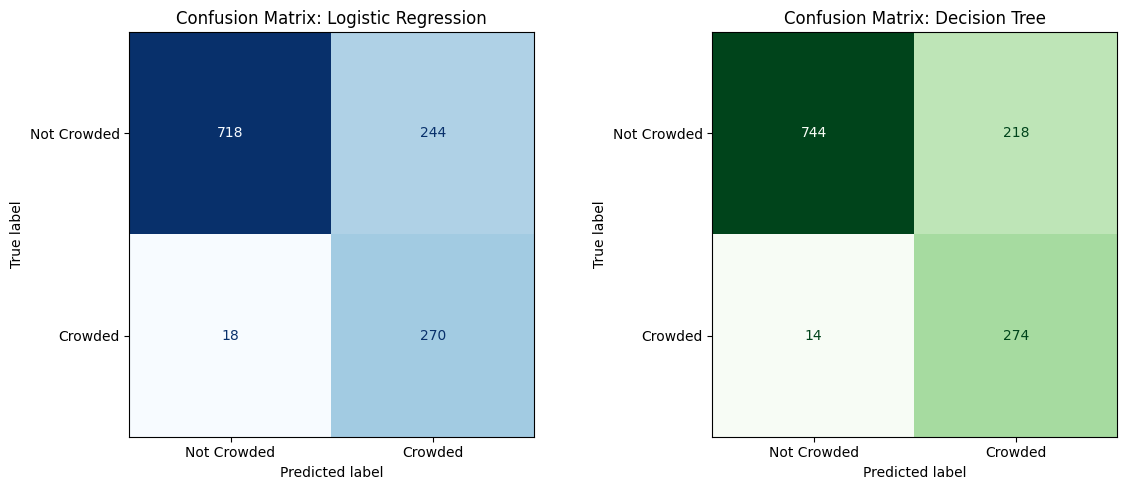

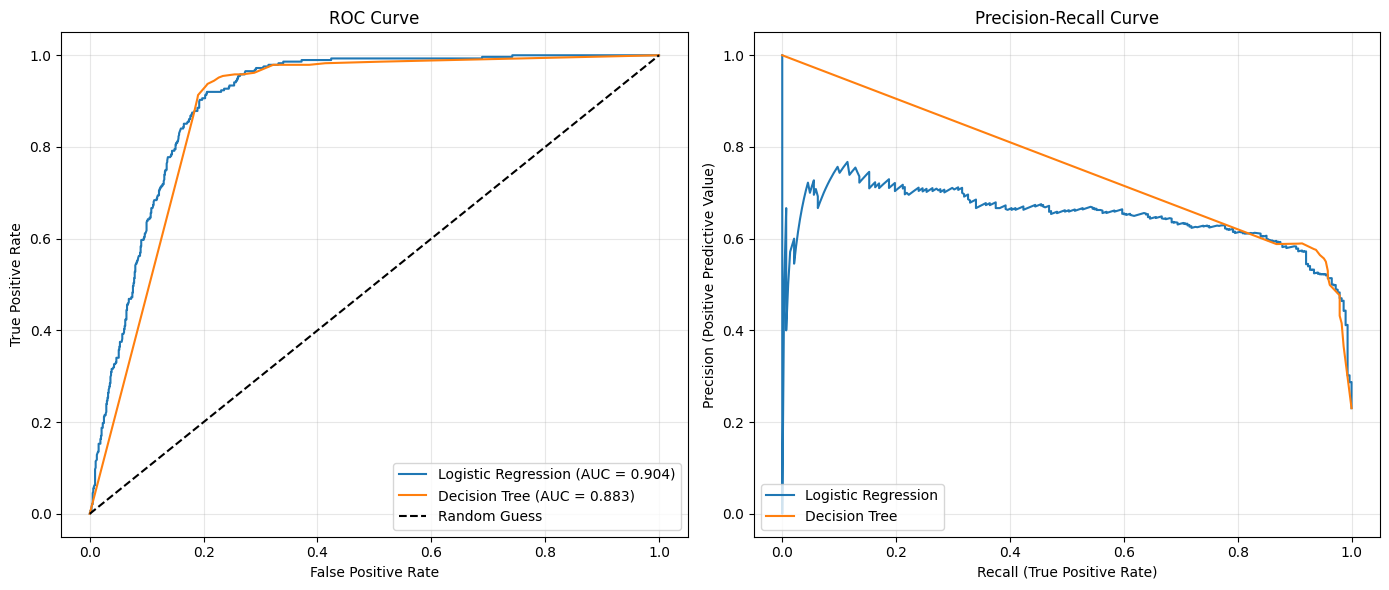

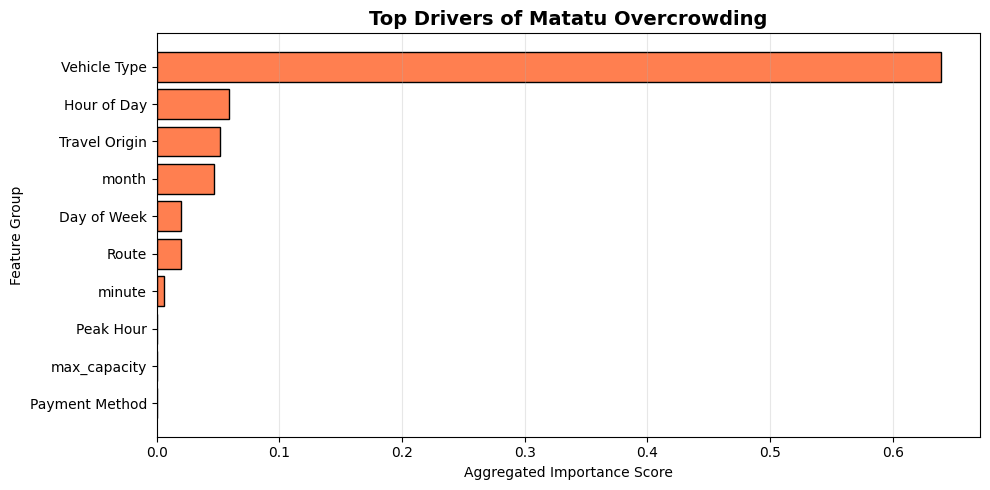

In [16]:
df = pd.read_csv('matatu_merged_clean.csv')

cols_to_drop = ['ride_id', 'timestamp_bin', 'seats_sold', 'occupancy_rate', 'is_overcrowded']
y = df['is_overcrowded']
X_raw = df.drop(columns=cols_to_drop)

X = pd.get_dummies(X_raw, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- 5-Fold Cross Validation (Robustness Check) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
tree_clf = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

cv_log = cross_val_score(log_reg, X_train, y_train, cv=cv, scoring='f1')
cv_tree = cross_val_score(tree_clf, X_train, y_train, cv=cv, scoring='f1')

print(f"Logistic Regression CV F1 Score: {cv_log.mean():.4f} (+/- {cv_log.std() * 2:.4f})")
print(f"Decision Tree CV F1 Score:       {cv_tree.mean():.4f} (+/- {cv_tree.std() * 2:.4f})\n")

log_reg.fit(X_train, y_train)
tree_clf.fit(X_train, y_train)

log_preds = log_reg.predict(X_test)
log_probs = log_reg.predict_proba(X_test)[:, 1]

tree_preds = tree_clf.predict(X_test)
tree_probs = tree_clf.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION CLASSIFICATION REPORT ===")
print(classification_report(y_test, log_preds))

print("=== DECISION TREE CLASSIFICATION REPORT ===")
print(classification_report(y_test, tree_preds))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, log_preds)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Not Crowded', 'Crowded'])
disp_log.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix: Logistic Regression')

cm_tree = confusion_matrix(y_test, tree_preds)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Not Crowded', 'Crowded'])
disp_tree.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix: Decision Tree')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)

axes[0].plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, log_probs):.3f})')
axes[0].plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {roc_auc_score(y_test, tree_probs):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

prec_log, rec_log, _ = precision_recall_curve(y_test, log_probs)
prec_tree, rec_tree, _ = precision_recall_curve(y_test, tree_probs)

axes[1].plot(rec_log, prec_log, label='Logistic Regression')
axes[1].plot(rec_tree, prec_tree, label='Decision Tree')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall (True Positive Rate)')
axes[1].set_ylabel('Precision (Positive Predictive Value)')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

importances = tree_clf.feature_importances_
feature_names = X.columns

grouped_importances = {}

for name, imp in zip(feature_names, importances):
    if name in ['centroid_lat', 'centroid_lon', 'gis_missing', 'route_count']:
        continue

    base_name = name
    if 'route_' in name: base_name = 'Route'
    elif 'travel_from_' in name: base_name = 'Travel Origin'
    elif 'day_of_week_' in name: base_name = 'Day of Week'
    elif 'car_type_' in name: base_name = 'Vehicle Type'
    elif 'payment_method_' in name: base_name = 'Payment Method'
    elif name == 'hour': base_name = 'Hour of Day'
    elif name == 'is_peak': base_name = 'Peak Hour'

    grouped_importances[base_name] = grouped_importances.get(base_name, 0) + imp

fi_df = pd.DataFrame(list(grouped_importances.items()), columns=['Feature', 'Importance'])
top_features = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(top_features['Feature'], top_features['Importance'], color='coral', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top Drivers of Matatu Overcrowding', fontsize=14, fontweight='bold')
plt.xlabel('Aggregated Importance Score')
plt.ylabel('Feature Group')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### Check 1: Test on future rides
This cell trains on the earliest 80% of rides and tests on the latest 20%. That is closer to real use, where the app predicts rides that have not happened yet. It trains new copies of the models, so `log_reg` and `tree_clf` above are not changed.

Compare these scores with the ones above. If they are similar, the result is reliable. If they are much lower, report these lower scores.

In [17]:
# Check 1: time-based split, to compare against the random split above
from sklearn.base import clone

df_t = pd.read_csv('matatu_merged_clean.csv').sort_values('timestamp_bin').reset_index(drop=True)
y_t = df_t['is_overcrowded']
X_t = pd.get_dummies(df_t.drop(columns=cols_to_drop), drop_first=True)

cut = int(len(df_t) * 0.8)
Xt_train, Xt_test = X_t.iloc[:cut], X_t.iloc[cut:]
yt_train, yt_test = y_t.iloc[:cut], y_t.iloc[cut:]

print(f"Train: first {cut} rides | Test: last {len(df_t) - cut} rides")
print(f"Overcrowded share  train: {yt_train.mean():.2%}  test: {yt_test.mean():.2%}\n")

for name, model in [('Logistic Regression', log_reg), ('Decision Tree', tree_clf)]:
    m = clone(model).fit(Xt_train, yt_train)
    p = m.predict(Xt_test)
    pr = m.predict_proba(Xt_test)[:, 1]
    print(f"{name:20s} F1: {f1_score(yt_test, p):.3f}   ROC AUC: {roc_auc_score(yt_test, pr):.3f}")

Train: first 4999 rides | Test: last 1250 rides
Overcrowded share  train: 28.13%  test: 2.72%

Logistic Regression  F1: 0.234   ROC AUC: 0.874
Decision Tree        F1: 0.288   ROC AUC: 0.795


### Save the model
A web app cannot retrain the model every time someone opens it, so we save the trained model to a file. This cell saves three files and downloads them:
- `model.pkl`: the trained model.
- `model_columns.json`: the list of columns the model expects, in order.
- `model_meta.json`: the scikit-learn version used. A model saved with one version can fail to load in another, so the app needs the same version.

The cell saves the decision tree. To save the logistic regression instead, change `tree_clf` to `log_reg` on the first line.

In [18]:
# Save the trained model for the web app
import joblib, json, sklearn

model_to_save = tree_clf   # change to log_reg to save that model instead

joblib.dump(model_to_save, 'model.pkl')
json.dump(list(X.columns), open('model_columns.json', 'w'))
json.dump({'sklearn_version': sklearn.__version__,
           'model': type(model_to_save).__name__,
           'target': 'is_overcrowded (occupancy >= 0.8)'},
          open('model_meta.json', 'w'), indent=2)
print('Saved model.pkl, model_columns.json, model_meta.json')
print('scikit-learn version used:', sklearn.__version__, '(use this version in requirements.txt)')

# Download the files to your computer (works in Colab only)
try:
    from google.colab import files
    for f in ['model.pkl', 'model_columns.json', 'model_meta.json']:
        files.download(f)
except ImportError:
    pass

Saved model.pkl, model_columns.json, model_meta.json
scikit-learn version used: 1.6.1 (use this version in requirements.txt)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Check 2: Test the saved model on one ride
This cell does what the web app will do. It loads the saved model, takes one ride described in plain columns, converts it to the same 0/1 columns the model learned on and prints a prediction. If this works, the same steps will work in `app.py`.

The important line is `reindex(columns=cols, fill_value=0)`. A single ride does not contain every possible day, route or vehicle type, so the missing 0/1 columns must be filled with 0 and put in the order the model expects.

In [19]:
# Check 2: reload the saved model and predict for one example ride
import joblib, json

model = joblib.load('model.pkl')
cols = json.load(open('model_columns.json'))

example = X_raw.iloc[[0]]                          # one real ride, as plain columns
print('Example ride:\n', example.T.to_string(), '\n')

# drop_first=False on purpose: with one row, drop_first=True would drop the only category
row = pd.get_dummies(example).reindex(columns=cols, fill_value=0)

prob = model.predict_proba(row)[0, 1]
print(f"Chance this ride is overcrowded: {prob:.1%}")
print("Prediction:", "Crowded" if prob >= 0.5 else "Not crowded")

Example ride:
                            0
route           Mombasa Road
travel_from           Migori
hour                       7
minute                    15
day_of_week          Tuesday
month                     10
car_type                 Bus
payment_method         Mpesa
is_peak                    1
max_capacity              49
route_count              8.0
centroid_lat        -1.38019
centroid_lon       36.896275
gis_missing            False 

Chance this ride is overcrowded: 18.9%
Prediction: Not crowded


# Part 3: Charts
These charts do not train anything. They show what the data looks like. They are also the best candidates for the web app and the report.

 Member 3: Statistical & Text Visualizer

### Load the data for the charts
Loads the clean CSV again into `df`, sets the chart style and prints the table size and the first rows.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('matatu_merged_clean.csv')
print(df.shape)
df.head()

(6249, 19)


,ride_id,route,travel_from,timestamp_bin,hour,minute,day_of_week,month,car_type,payment_method,is_peak,seats_sold,max_capacity,occupancy_rate,is_overcrowded,route_count,centroid_lat,centroid_lon,gis_missing
0,1442,Mombasa Road,Migori,2017-10-17 07:00:00,7,15,Tuesday,10,Bus,Mpesa,1,1,49,0.020408,0,8.0,-1.380190,36.896275,False
1,14304,Mombasa Road,Kisii,2017-11-14 05:00:00,5,10,Tuesday,11,Bus,Mpesa,1,1,49,0.020408,0,8.0,-1.380190,36.896275,False
2,5437,Mombasa Road,Migori,2017-11-19 07:00:00,7,12,Sunday,11,Bus,Mpesa,1,1,49,0.020408,0,8.0,-1.380190,36.896275,False
3,5710,Ngong Road,Keroka,2017-11-26 07:00:00,7,5,Sunday,11,Bus,Mpesa,1,1,49,0.020408,0,20.0,-1.324771,36.742868,False
4,13761,Mombasa Road,Kisii,2017-11-27 05:00:00,5,0,Monday,11,shuttle,Mpesa,1,2,11,0.181818,0,8.0,-1.380190,36.896275,False


### 1. Correlation Heatmap
Numeric ride features against `is_overcrowded` and `occupancy_rate`. `seats_sold` and `occupancy_rate` are excluded from any *modeling* feature matrix (leakage, per Member 1's note) but are kept here for the visualization since this is exploratory, not a feature matrix.

This cell measures how strongly each pair of columns moves together, from -1 to +1, and draws the result as a colour grid. Strong red or blue cells mean a strong relationship. White cells mean little or none. Look at the `is_overcrowded` row to see which factors relate most to crowding. The chart is saved as `corr_heatmap.png`.

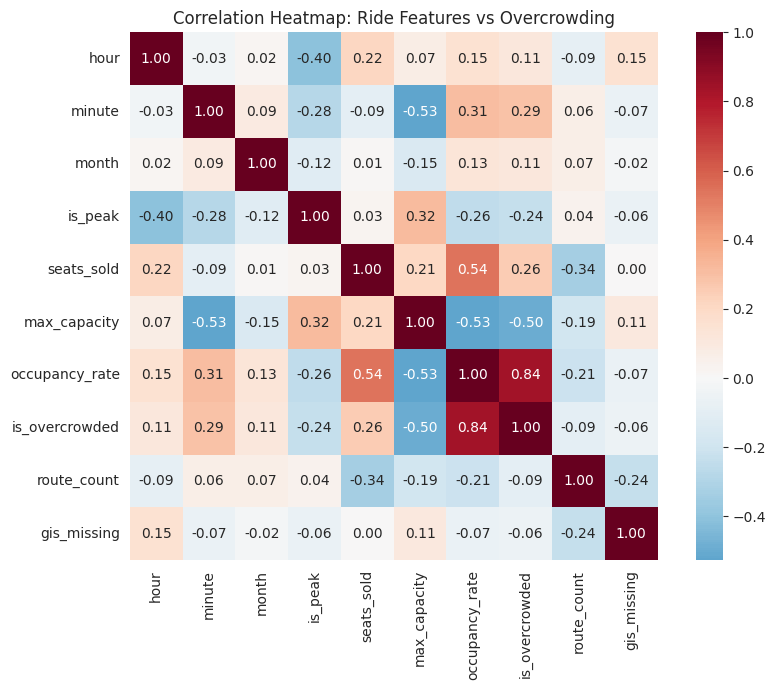

In [21]:
corr_cols = ['hour', 'minute', 'month', 'is_peak', 'seats_sold', 'max_capacity',
             'occupancy_rate', 'is_overcrowded', 'route_count', 'gis_missing']
corr_df = df[corr_cols].copy()
corr_df['gis_missing'] = corr_df['gis_missing'].astype(int)
corr = corr_df.corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap: Ride Features vs Overcrowding')
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150)
plt.show()

### 2. Peak-Hour Overcrowding
Overcrowding rate by hour of day, with the overall dataset average (23%) marked for reference.

This cell works out the share of overcrowded rides for each hour of the day and draws one bar per hour. The red dashed line is the overall average, now calculated from the data instead of typed by hand. Bars above the line are busier than average. Saved as `peak_hour.png`.

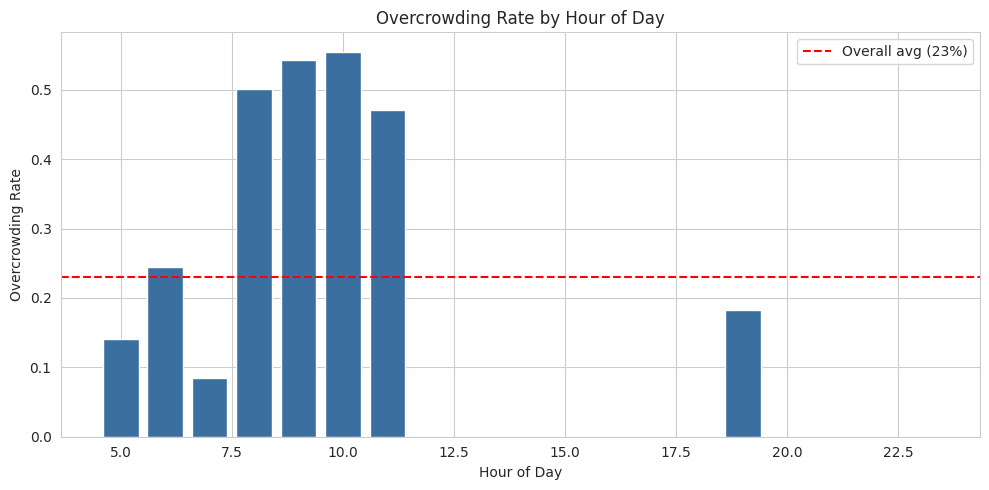

In [22]:
hourly = df.groupby('hour')['is_overcrowded'].mean().reset_index()

plt.figure(figsize=(10,5))
plt.bar(hourly['hour'], hourly['is_overcrowded'], color='#3b6fa0')
plt.axhline(df['is_overcrowded'].mean(), color='red', linestyle='--', label=f"Overall avg ({df['is_overcrowded'].mean():.0%})")
plt.xlabel('Hour of Day')
plt.ylabel('Overcrowding Rate')
plt.title('Overcrowding Rate by Hour of Day')
plt.legend()
plt.tight_layout()
plt.savefig('peak_hour.png', dpi=150)
plt.show()

### 3. Overcrowding by Corridor
Directly complements Member 2's map heatmaps - same corridors, quantified. Mombasa Road stands out sharply.

This cell does the same as the last chart, but for each road corridor. A taller bar means a larger share of overcrowded rides. The table below the chart shows the exact rates and the number of rides per corridor. A corridor with few rides has a less reliable rate. Saved as `corridor.png`.

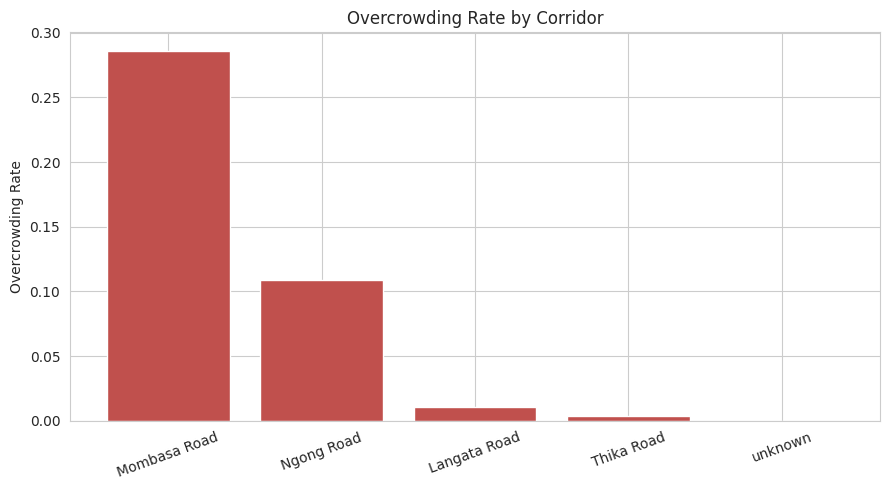

,route,mean,count
1,Mombasa Road,0.286007,4888
2,Ngong Road,0.108434,332
0,Langata Road,0.010582,378
3,Thika Road,0.003472,576
4,unknown,0.000000,75


In [23]:
route_rate = df.groupby('route')['is_overcrowded'].agg(['mean','count']).reset_index()
route_rate = route_rate.sort_values('mean', ascending=False)

plt.figure(figsize=(9,5))
plt.bar(route_rate['route'], route_rate['mean'], color='#c0504d')
plt.ylabel('Overcrowding Rate')
plt.title('Overcrowding Rate by Corridor')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('corridor.png', dpi=150)
plt.show()

route_rate

### 4. Day of Week × Peak/Off-Peak
Where in the week overcrowding concentrates, split by peak vs off-peak travel.

This cell draws a grid with the days of the week down the side and off-peak/peak (0 and 1) across the top. Each square shows the share of overcrowded rides. Darker colours mean more crowding. Saved as `day_peak.png`.

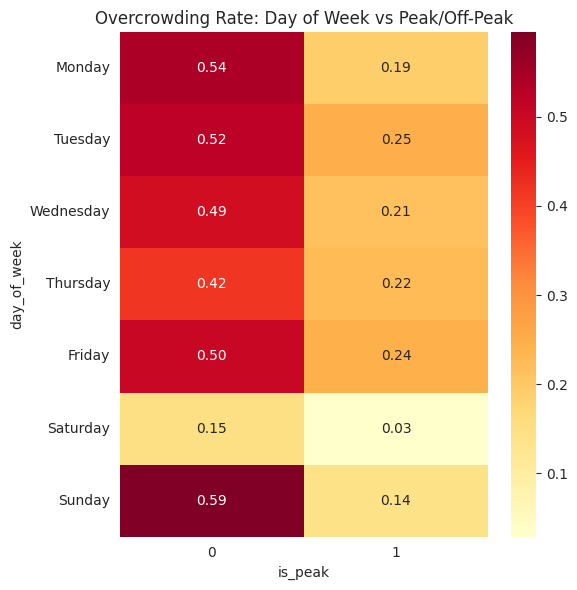

In [24]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.pivot_table(index='day_of_week', columns='is_peak', values='is_overcrowded', aggfunc='mean')
pivot = pivot.reindex(day_order)

plt.figure(figsize=(6,6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Overcrowding Rate: Day of Week vs Peak/Off-Peak')
plt.xlabel('is_peak')
plt.tight_layout()
plt.savefig('day_peak.png', dpi=150)
plt.show()

### 5. Bonus Panel - Waze Driver Behaviour (substitute for text/sentiment chart)

`waze_dataset.csv` is a generic app-usage/churn dataset (not Nairobi-specific, no text). It's used here only as a rough behavioural reference - does more frequent driving relate to app retention - standing in for the tweet sentiment chart that couldn't be built. This is flagged as a substitution in the report, not presented as equivalent analysis.

This cell loads `waze_dataset.csv`, removes unlabelled rows and draws a box plot of driving days for users who stayed and users who churned. It needs `waze_dataset.csv` in the Colab file panel. It is not matatu data, so treat it as background only. Saved as `waze_bonus.png`.

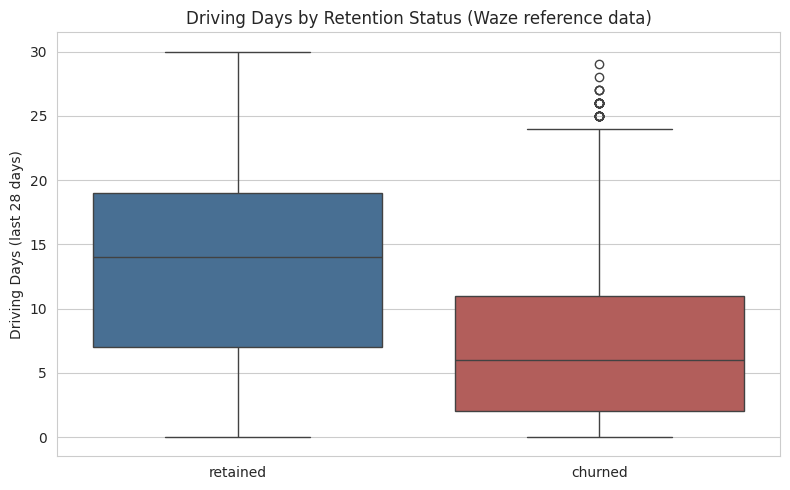

In [25]:
waze = pd.read_csv('waze_dataset.csv')
waze_clean = waze.dropna(subset=['label'])

plt.figure(figsize=(8,5))
sns.boxplot(data=waze_clean, x='label', y='driving_days', hue='label',
            palette=['#3b6fa0','#c0504d'], legend=False)
plt.title('Driving Days by Retention Status (Waze reference data)')
plt.xlabel('')
plt.ylabel('Driving Days (last 28 days)')
plt.tight_layout()
plt.savefig('waze_bonus.png', dpi=150)
plt.show()

# Part 4: Data sources, assumptions and limits

## Data sources
The raw data files are not stored in the GitHub repo. Download them from the original sources:

| Data | Where to get it | Used for |
|---|---|---|
| Matatu ticket data | [Zindi: Traffic Jam, Predicting People's Movement into Nairobi](https://zindi.africa/competitions/traffic-jam-predicting-peoples-movement-into-nairobi/data) (free Zindi account and acceptance of the competition rules required) | Rides, times, vehicle types, the target |
| Route and stop map data (`GIS_DATA_2019.zip`) | [Digital Matatus project](https://digitalmatatus.com/) | Corridor labels and map positions |
| Waze user data (`waze_dataset.csv`) | Kaggle, search for "Waze dataset" (add the exact link you used here) | Background reference only |

Please check each source's terms before sharing any file that contains its data.

## Assumptions
- **Corridor mapping.** The Zindi data does not say which road a matatu uses to enter Nairobi. The team assigned each origin town to a corridor by judgement. For example, Kisii and Migori are assigned to Mombasa Road, Homa Bay to Langata Road and Keroka to Ngong Road. Any result about corridors, including "Mombasa Road is the most overcrowded", depends on this mapping.
- **Route tagging.** Routes in the map data are tagged by keywords in their names, so a few may be tagged wrongly.
- **Overcrowded means 80% full.** The 80% cut-off was chosen by the team. A different cut-off would change the results.

Text for the report:

> The Zindi dataset records the origin town of each ride but not the road used to enter Nairobi. We assigned each origin town to a corridor (Mombasa Road, Langata Road, Ngong Road or Thika Road) based on our own judgement of its likely route. This mapping was not verified against external data. All corridor-level findings in this report depend on it and should be read as indicative, not exact.

## Limits
- The map features (`centroid_lat`, `centroid_lon`, `route_count`) are constant for each corridor, so they repeat the corridor and add nothing new.
- The Waze data is not about matatus. It is background only.
- Scores from the random split may be too high. Use the scores from Check 1 when you report how well the model works on future rides.